In [1]:
import pandas as pd
from tensorflow.keras import Sequential, callbacks
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, InputLayer, Activation
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import optuna
import mlflow
import dagshub

In [2]:
train_df = pd.read_csv("/content/train_df.csv")
test_df = pd.read_csv("/content/test_df.csv")

X_train = train_df.drop(columns=["time"])
X_test = test_df.drop(columns=["time"])

y_train = train_df["time"]
y_test = test_df["time"]

In [3]:
def objective(trial):

  n_layers = trial.suggest_int("layers", 1, 5)
  units = trial.suggest_int("units", 64, 512,log=True)
  dropout = trial.suggest_float("dropout", 0.0, 0.5)
  lr = trial.suggest_float("learning_rate", 1e-4, 1e-1, log=True)

  model = Sequential()

  model.add(InputLayer(shape=(X_train.shape[1], )))

  for _ in range(n_layers):

      model.add(Dense(units, use_bias=False))
      model.add(BatchNormalization())
      model.add(Activation("relu"))
      model.add(Dropout(dropout))

  model.add(Dense(1))

  model.compile(optimizer=Adam(learning_rate=lr),
                loss="mae")

  callback = callbacks.EarlyStopping(
      patience=10, restore_best_weights=True
  )

  model.fit(X_train, y_train, validation_data=(X_test, y_test),
            epochs=50, batch_size=128, callbacks=callback)

  y_pred = model.predict(X_test)

  mae = mean_absolute_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)

  trial.set_user_attr("r2_score", r2)

  return mae

In [17]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30)

[I 2026-02-19 10:31:54,199] A new study created in memory with name: no-name-17376f59-44a0-4615-935c-e42b8d5e6655


Epoch 1/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.9810 - val_loss: 0.5532
Epoch 2/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6504 - val_loss: 0.4926
Epoch 3/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5605 - val_loss: 0.4818
Epoch 4/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5259 - val_loss: 0.4675
Epoch 5/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5104 - val_loss: 0.4645
Epoch 6/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5012 - val_loss: 0.4581
Epoch 7/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4966 - val_loss: 0.4551
Epoch 8/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4844 - val_loss: 0.4526
Epoch 9/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4826 - val_loss: 0.4469
Epoch 10/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4778 - val_loss: 0.4460
Epoch 11/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4798 - val_loss: 0.4445
Epoch 12/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

[I 2026-02-19 10:32:38,502] Trial 0 finished with value: 0.41775938455511935 and parameters: {'layers': 1, 'units': 91, 'dropout': 0.4633829074963971, 'learning_rate': 0.0005573314000351782}. Best is trial 0 with value: 0.41775938455511935.


Epoch 1/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 1.0735 - val_loss: 0.5926
Epoch 2/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6866 - val_loss: 0.5367
Epoch 3/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5816 - val_loss: 0.5058
Epoch 4/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5437 - val_loss: 0.4820
Epoch 5/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5243 - val_loss: 0.4820
Epoch 6/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5107 - val_loss: 0.4548
Epoch 7/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4962 - val_loss: 0.4486
Epoch 8/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4934 - val_loss: 0.4484
Epoch 9/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4791 - val_loss: 0.4372
Epoch 10/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4745 - val_loss: 0.4257
Epoch 11/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4720 - val_loss: 0.4200
Epoch 12/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/ste

[I 2026-02-19 10:33:32,430] Trial 1 finished with value: 0.34698421610090285 and parameters: {'layers': 3, 'units': 102, 'dropout': 0.4333953013033758, 'learning_rate': 0.0008188414887432358}. Best is trial 1 with value: 0.34698421610090285.


...

[I 2026-02-19 10:57:22,902] Trial 27 finished with value: 0.3407297489469233 and parameters: {'layers': 5, 'units': 212, 'dropout': 0.06884716543069773, 'learning_rate': 0.0066464302461653356}. Best is trial 21 with value: 0.3328376708082149.


Epoch 1/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - loss: 0.7032 - val_loss: 0.4793
Epoch 2/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.4643 - val_loss: 0.4175
Epoch 3/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4265 - val_loss: 0.3990
Epoch 4/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4136 - val_loss: 0.3884
Epoch 5/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3964 - val_loss: 0.3766
Epoch 6/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3932 - val_loss: 0.3676
Epoch 7/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3866 - val_loss: 0.3720
Epoch 8/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3765 - val_loss: 0.3672
Epoch 9/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3758 - val_loss: 0.3543
Epoch 10/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3713 - val_loss: 0.3516
Epoch 11/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3659 - val_loss: 0.3556
Epoch 12/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/s

[I 2026-02-19 10:58:22,296] Trial 28 finished with value: 0.3351596433379142 and parameters: {'layers': 4, 'units': 275, 'dropout': 0.1740874924520704, 'learning_rate': 0.0016430006917198753}. Best is trial 21 with value: 0.3328376708082149.


Epoch 1/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.6659 - val_loss: 0.4928
Epoch 2/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4913 - val_loss: 0.4911
Epoch 3/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4910 - val_loss: 0.4502
Epoch 4/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4903 - val_loss: 0.5030
Epoch 5/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4855 - val_loss: 0.4669
Epoch 6/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4808 - val_loss: 0.4354
Epoch 7/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4756 - val_loss: 0.5268
Epoch 8/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4904 - val_loss: 0.4433
Epoch 9/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4797 - val_loss: 0.4493
Epoch 10/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4781 - val_loss: 0.4505
Epoch 11/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4796 - val_loss: 0.4333
Epoch 12/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/ste

[I 2026-02-19 10:59:09,657] Trial 29 finished with value: 0.426302600772413 and parameters: {'layers': 1, 'units': 127, 'dropout': 0.28477567869100995, 'learning_rate': 0.05314269659385843}. Best is trial 21 with value: 0.3328376708082149.


In [8]:
import json

# best_params = study.best_params

with open("/content/best_params.json", "r") as file:
    best_params = json.load(file)

n_layers = best_params["layers"]
units = best_params["units"]
dropout = best_params["dropout"]
lr = best_params["learning_rate"]

model = Sequential()

model.add(InputLayer(shape=(X_train.shape[1], )))

for _ in range(n_layers):

    model.add(Dense(units, use_bias=False))
    model.add(BatchNormalization())
    model.add(Activation("relu"))
    model.add(Dropout(dropout))

model.add(Dense(1))

model.compile(optimizer=Adam(learning_rate=lr),
              loss="mae")

callback = callbacks.EarlyStopping(
    patience=10, restore_best_weights=True
)

history = model.fit(X_train, y_train, validation_data=(X_test, y_test),
            epochs=500, batch_size=128, callbacks=callback)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mae, r2

Epoch 1/500
262/262 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - loss: 0.6811 - val_loss: 0.5169
Epoch 2/500
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4561 - val_loss: 0.4157
Epoch 3/500
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4191 - val_loss: 0.3973
Epoch 4/500
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4063 - val_loss: 0.3801
Epoch 5/500
262/262 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.3907 - val_loss: 0.3611
Epoch 6/500
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3810 - val_loss: 0.3601
Epoch 7/500
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3767 - val_loss: 0.3580
Epoch 8/500
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3763 - val_loss: 0.3687
Epoch 9/500
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3713 - val_loss: 0.3751
Epoch 10/500
262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.3682 - val_loss: 0.3603
Epoch 11/500
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3696 - val_loss: 0.3597
Epoch 12/500
262/262 ━━━━━━━━━━━━━━━━━

(0.3331363589243679, 0.8209895170216328)

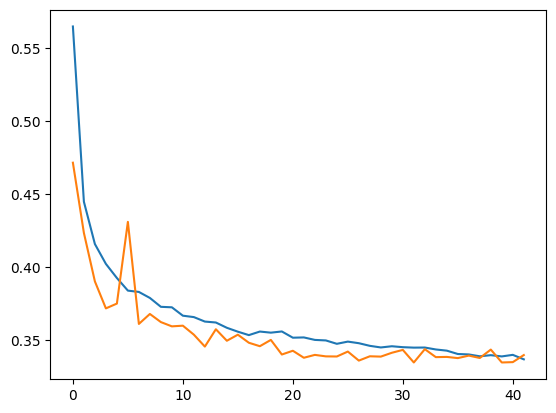

In [25]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label ="loss")
plt.plot(history.history["val_loss"], label ="val_loss")

plt.show()

In [27]:
import json

with open("best_params.json", "w") as file:

  json.dump(study.best_params, file, indent=4)

In [9]:
mlflow.set_tracking_uri("https://dagshub.com/PriyanshuMewal/delivery-time-prediction.mlflow")

dagshub.init(repo_owner='PriyanshuMewal', repo_name='delivery-time-prediction', mlflow=True)

mlflow.set_experiment("model selection")


❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=30778186-46c7-4f75-bb90-2f7ee0b239fd&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=d1ab8df6733f0bf00854c4fbee2c15ff3f037fd81ecc7f8f9f7a1c0a1d9ec2fe




Accessing as PriyanshuMewal

Initialized MLflow to track repo "PriyanshuMewal/delivery-time-prediction"

Repository PriyanshuMewal/delivery-time-prediction initialized!

<Experiment: artifact_location='mlflow-artifacts:/f325cd14154d4534b165ce6c35901c0c', creation_time=1771329376929, experiment_id='3', last_update_time=1771329376929, lifecycle_stage='active', name='model selection', tags={'mlflow.experimentKind': 'custom_model_development'}>

In [12]:
with mlflow.start_run(run_name="ANN"):

  # log parameters:
  parameters = {"model": "ANN"}

  parameters.update(best_params)
  mlflow.log_params(best_params)

  # log metrics:
  mlflow.log_metric("mean_absolute_error", mae)
  mlflow.log_metric("r2_score", r2)

  # log model:
  # signature = sklearn.models.infer_signature(X_test, y_pred)
  # mlflow.sklearn.log_model(model, signature=signature)

  # log dataset:
  # mlflow.log_artifact("/content/test_df.csv")
  # mlflow.log_artifact("/content/train_df.csv")


🏃 View run ANN at: https://dagshub.com/PriyanshuMewal/delivery-time-prediction.mlflow/#/experiments/3/runs/dc29af06c7174209b708bdf096cc966b
🧪 View experiment at: https://dagshub.com/PriyanshuMewal/delivery-time-prediction.mlflow/#/experiments/3
